In [1]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

file_path = '../Dataset/preprocessed_combined_data_weekday_3-2022_3-2023.csv'

df = pd.read_csv(file_path)

df.set_index('Date Time', inplace=True)

display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,1,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0


In [2]:
X = df.drop('kW', axis = 1)
y = df.kW

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Split data into training and temporary data (80% training, 20% temporary)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split temporary data into testing and validation sets (50% testing, 50% validation)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


#Standardize features by removing the mean and scaling to unit variance
scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 128)               2432      
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 1)                 65        
                                                                 
Total params: 10753 (42.00 KB)
Trainable params: 10753 (42.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/1000
874/874 [==============================] - 5s 4ms/step - loss: 41268.9414 - mae: 161.4214 - val_loss: 32858.5117 - val_mae: 134.0567
Epoch 2/1000
874/874 [==============================] - 4s 4ms/step - loss: 27551.5762 - mae: 111.6897 - val_loss: 22845.4609 - val_mae:

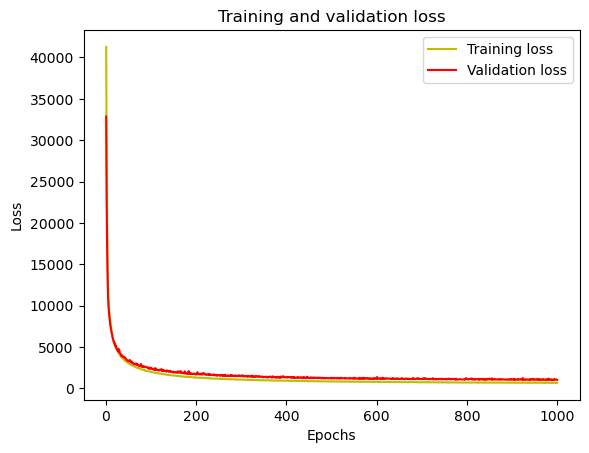

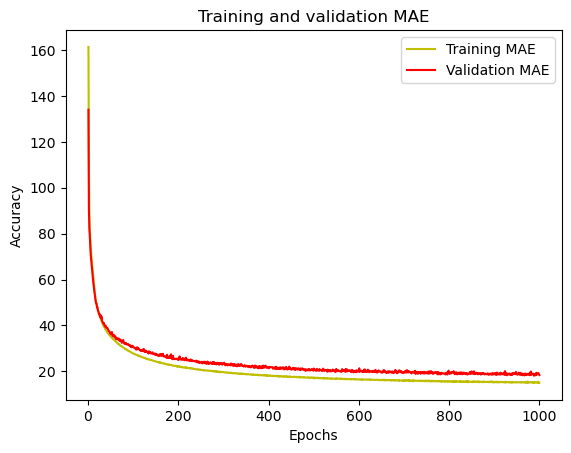

110/110 [==============================] - 0s 2ms/step
Training R^2: 0.9566767424038739
Validation R^2: 0.9302372866686859


In [5]:
epoch_values = [1000]

for epoch in epoch_values: 
    # define the model
    # Experiment with deeper and wider networks

    # Sequential constructor automatically/implicitly creates an input layer when the first layer is added to the model. Its shape is determined by the "input_dim" parameter of the first layer
    model = Sequential()

    # Dense layers (all connected) are added to the neural network with the specified neuron amount
    # 128 neurons in the 1st hidden layer 
    model.add(Dense(128, input_dim=18, activation='relu'))

    # 64 neurons in the 2nd hidden layer
    model.add(Dense(64, activation='tanh'))

    # Output layer, linear activation function does nothing except adding the results of previous neurons together
    model.add(Dense(1, activation='linear'))

    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    model.summary()

    history = model.fit(X_train_scaled, y_train, validation_data=[X_val_scaled, y_val] , epochs = epoch)
    #validation_data=[X_test, y_test]

    #plot the training and validation accuracy and loss at each epoch
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.plot(epochs, loss, 'y', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


    acc = history.history['mae']
    val_acc = history.history['val_mae']
    plt.plot(epochs, acc, 'y', label='Training MAE')
    plt.plot(epochs, val_acc, 'r', label='Validation MAE')
    plt.title('Training and validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()


    # 1. Obtain predictions for both training and testing sets
    train_predictions = model.predict(X_train_scaled)
    val_predictions = model.predict(X_val_scaled)

    # 2. Calculate R^2 scores
    train_r2 = r2_score(y_train, train_predictions)
    val_r2 = r2_score(y_val, val_predictions)

    print("Training R^2:", train_r2)
    print("Validation R^2:", val_r2)

In [7]:
#from keras.callbacks import ModelCheckpoint

from keras.models import load_model

# Save the model
model.save('R_model.keras')


In [8]:
additional_epochs = 1000

history_continued = model.fit(X_train_scaled, y_train, validation_data=[X_val_scaled, y_val], epochs=additional_epochs)

Epoch 1/1000
874/874 [==============================] - 3s 3ms/step - loss: 704.0371 - mae: 15.2641 - val_loss: 1050.0378 - val_mae: 18.4748
Epoch 2/1000
874/874 [==============================] - 3s 3ms/step - loss: 677.3447 - mae: 14.9953 - val_loss: 1072.4546 - val_mae: 18.7665
Epoch 3/1000
874/874 [==============================] - 3s 3ms/step - loss: 687.0539 - mae: 15.0634 - val_loss: 1039.4363 - val_mae: 18.2782
Epoch 4/1000
874/874 [==============================] - 3s 3ms/step - loss: 673.3123 - mae: 14.9404 - val_loss: 1063.6953 - val_mae: 18.5001
Epoch 5/1000
874/874 [==============================] - 3s 3ms/step - loss: 695.2375 - mae: 15.1455 - val_loss: 1029.8324 - val_mae: 18.0395
Epoch 6/1000
874/874 [==============================] - 3s 3ms/step - loss: 689.9685 - mae: 15.1182 - val_loss: 1128.9966 - val_mae: 19.4808
Epoch 7/1000
874/874 [==============================] - 2s 3ms/step - loss: 691.5297 - mae: 15.1496 - val_loss: 1066.8608 - val_mae: 18.5208
Epoch 8/1000


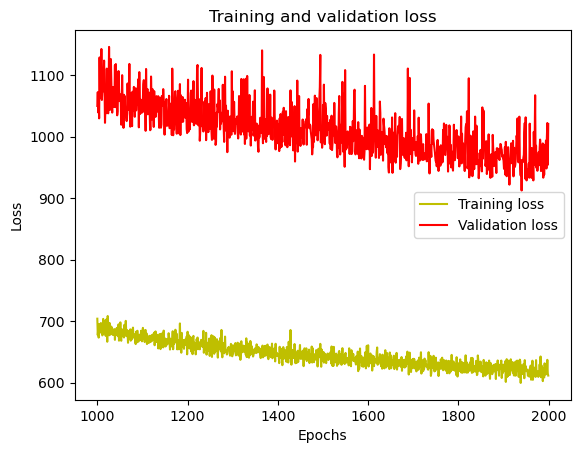

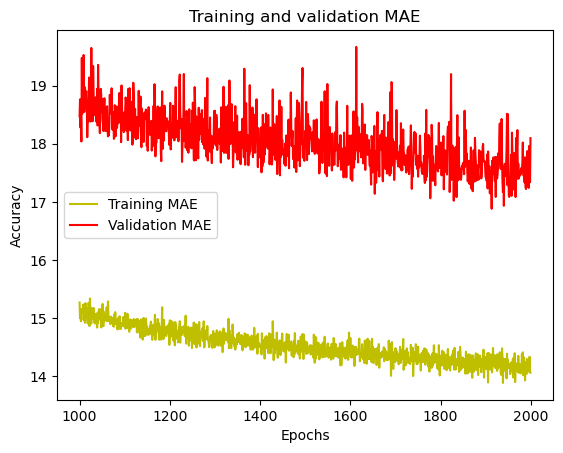

In [9]:
loss2 = history_continued.history['loss']
val_loss2 = history_continued.history['val_loss']
epochs2 = range(1000,2000)
plt.plot(epochs2, loss2, 'y', label='Training loss')
plt.plot(epochs2, val_loss2, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


acc2 = history_continued.history['mae']
val_acc2 = history_continued.history['val_mae']
plt.plot(epochs2, acc2, 'y', label='Training MAE')
plt.plot(epochs2, val_acc2, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [10]:
# Save the model
model.save('R_model2.keras')

In [11]:
# 1. Obtain predictions for both training and testing sets
train_predictions2 = model.predict(X_train_scaled)
val_predictions2 = model.predict(X_val_scaled)

# 2. Calculate R^2 scores
train_r2 = r2_score(y_train, train_predictions2)
val_r2 = r2_score(y_val, val_predictions2)

print("Training R^2:", train_r2)
print("Validation R^2:", val_r2)

110/110 [==============================] - 0s 2ms/step
Training R^2: 0.957114300959636
Validation R^2: 0.9314440452260402
